# 20.17. Полупространство и точность восстановления тканевых параметров

**Назначение:** продолжение 20.16; проверка двух способов расчёта без объёмной конечноэлементной сетки. Целевая величина — точность обратного восстановления эффективных удельных сопротивлений мягких тканей $\rho_1$ и лёгкого $\rho_2$. FEM (finite element method) — метод конечных элементов. Этап является вычислительным исследованием, а не экспериментальной валидацией методики.

**Главный результат.** В рассмотренном положении сборок обе модели с плоской кожей и криволинейным лёгким в полупространстве дают оценку $\rho_2$ на верхней границе допустимого диапазона во всех 16 синтетических состояниях. Медианная абсолютная относительная ошибка $\rho_2$ составляет 52,85%. У модели с переменным сечением лёгкого **внутри тела по КТ** соответствующая ошибка равна 2,49%. Поэтому простое сохранение кривизны лёгкого при замене наружной границы плоскостью здесь недостаточно.

Ниже последовательно проверяются постановка, численная реализация, точность восстановления, дыхательные и пульсовые изменения и стоимость расчёта. Числа в таблицах и рисунках читаются из сохранённых результатов. Меньшая ошибка относительно КТ/FEM означает лучшую согласованность с этим вычислительным референсом; она не доказывает точность по отношению к неизвестным сопротивлениям живых тканей.


In [1]:
from pathlib import Path
import sys,json
import pandas as pd
import numpy as np
from IPython.display import display,Markdown
roots=[Path.cwd(),*Path.cwd().parents]
root=next(p for p in roots if (p/'MATLAB_TRKG4_real_subjects').is_dir())
sys.path.insert(0,str(root/'MATLAB_TRKG4_real_subjects/tools'))
from halfspace_report_figures import show,read,ORDER,LABEL,SOURCE
g=json.loads((SOURCE/'geometry.json').read_text(encoding='utf-8'))
display(Markdown('**Таблица 1. Фиксированные условия вычислительного опыта.**'))
display(pd.DataFrame([
 ['Источник данных','Синтетические импедансы двухтканной КТ/FEM-модели'],
 ['Место','C01, условный кандидат предшествующего поиска'],
 ['Основные электроды','PEM; для полупространства сохранены s,t, глубина d=0'],
 ['Размеры, мм','50, 60, 70, 80, 90, 110, 120, 130, 140'],
 ['Заданные ρ₁, Ом·м','2; 4; 6; 8'],
 ['Заданные ρ₂, Ом·м','10; 14; 18; 22'],
 ['Главный критерий','Ошибка восстановления известных ρ₁ и ρ₂'],
],columns=['Условие','Принятое значение']).style.hide(axis='index'))
d=read('inverse_recovery')
rows=[]
for model in ORDER:
 a=d[d.model==model]
 rows.append([LABEL[model],np.median(abs(a.error1_pct)),np.median(abs(a.error2_pct)),max(abs(a.error2_pct)),int(a.on_bound.sum())])
display(Markdown('**Таблица 2. Ошибки восстановления в 16 состояниях.**'))
display(pd.DataFrame(rows,columns=['Модель','Медиана |ошибки ρ₁|, %','Медиана |ошибки ρ₂|, %','Максимум |ошибки ρ₂|, %','Решений на границе']).style.hide(axis='index').format(precision=3))


**Таблица 1. Фиксированные условия вычислительного опыта.**

Условие,Принятое значение
Источник данных,Синтетические импедансы двухтканной КТ/FEM-модели
Место,"C01, условный кандидат предшествующего поиска"
Основные электроды,"PEM; для полупространства сохранены s,t, глубина d=0"
"Размеры, мм","50, 60, 70, 80, 90, 110, 120, 130, 140"
"Заданные ρ₁, Ом·м",2; 4; 6; 8
"Заданные ρ₂, Ом·м",10; 14; 18; 22
Главный критерий,Ошибка восстановления известных ρ₁ и ρ₂


**Таблица 2. Ошибки восстановления в 16 состояниях.**

Модель,"Медиана |ошибки ρ₁|, %","Медиана |ошибки ρ₂|, %","Максимум |ошибки ρ₂|, %",Решений на границе
КТ/FEM,0.000,0.000,0.000,0
"М3, тело по КТ",0.080,2.755,15.490,1
"М4, тело по КТ",0.017,2.494,7.864,1
М3-H,16.538,52.851,140.741,16
М4-H,17.051,52.851,140.741,16
"Плоская, проекция",18.145,52.851,140.741,16
"Плоская, номинал",17.015,52.851,140.741,16


**Таблицы 1–2. Условия опыта и сводка восстановления.** Ошибка каждого параметра определена как $100(\widehat\rho_j-\rho_j^\ast)/\rho_j^\ast$; в сводке приведены медианы её абсолютного значения. Звёздочкой обозначено известное значение, заданное при синтетическом расчёте. Признак достижения границы нужен для интерпретации: ограниченная оценка может почти не меняться при возмущении входа потому, что оптимизатор уже не может увеличить параметр.

Диапазоны перенесены из 20.14: $\rho_1\in[1{,}3774;10]$, $\rho_2\in[9{,}7413;24{,}0741]$ Ом·м. Они опираются на данные IT'IS v5, частотный ориентир 50 кГц и литературные сведения для низких частот [5]. Это рабочие ограничения эффективной двухтканной модели, а не универсальные физиологические нормы. Основные тесты выполнены внутри них; выход за границу не используется для улучшения результата.


## 1. Задача, происхождение входов и ограничения

Задача — определить, какое сокращение индивидуальной КТ-геометрии сохраняет точность оценки $\rho_1,\rho_2$ и их изменений. КТ считается достоверным источником геометрии. Электрические параметры по КТ не известны: в вычислительном эксперименте их задают, рассчитывают синтетические импедансы референсным методом, затем восстанавливают другой моделью.

Взято положение C01 из предшествующей ветки 20.10/20.16: центр $(-187{,}5;\,31{,}0514;\,-138{,}0514)$ мм и угол $14^\circ$ в исходной системе координат. Это **условный кандидат дискретного поиска при ранее заданных сопротивлениях**, а не доказанное оптимальное положение и не независимо подтверждённое место реального монтажа. В текущем опыте его фиксируют, чтобы сравнивать модели на общих исходных данных. Расстояние от кожи в центре сборки $(s=t=0)$ вдоль локальной оси глубины $d$ до первого пересечения лёгкого, рассчитанное по принятой КТ-геометрии, составляет $h(0)\approx67{,}00$ мм.

Использованы девять размеров боковой сборки: 50, 60, 70, 80, 90, 110, 120, 130 и 140 мм. Для этого испытуемого запись 100 мм является копией 90 мм и отдельным измерением не считается. Здесь размерный ряд задаёт девять вычислительных монтажей; экспериментальные импедансы в новую синтетическую подгонку не включены.

В основной серии используется **точечная модель электродов PEM (point electrode model)**: ток вводится и напряжение считывается в узлах исходной FEM-сетки. При переносе в полупространство координаты $s,t$ каждого фактического узла сохраняются, а глубина $d$ заменяется нулём. Максимальная величина этой проекции — 12,77 мм. Поэтому совпадают исходное расположение и правило переноса, но не трёхмерная наружная поверхность. Полная модель конечных электродов CEM (complete electrode model) проверяется отдельно в разделе 9.

В модели только две области с вещественными скалярными сопротивлениями. Лёгкое задаётся его маской; всё вне неё — единый фон с $\rho_1$, включая рёбра, сердце и ткань ниже диафрагмы. Такое объединение является **допущением**, а не равенством физических свойств этих тканей. Диафрагма не вводит третьего неизвестного сопротивления. Частотная дисперсия, анизотропия и комплексная проводимость в данном опыте не учитываются.

Чтобы решение было интерпретируемым, сначала нужно проверить сам расчёт поля. Поэтому до сравнения обратных оценок ниже задаются геометрия и математический оператор, а затем выполняются независимые численные контроли.


## 2. Две модели криволинейного включения без FEM

### 2.1. Геометрия и краевая задача

Ось $s$ направлена вдоль сборки, $t$ — поперёк неё, $d>0$ — вглубь тела от плоскости кожи $d=0$. Для потенциала решается
$$\nabla\cdot(\sigma\nabla u)=0,\qquad \sigma_j=1/\rho_j,$$
где $u$ — потенциал, $\sigma$ — проводимость, $\rho_j$ — сопротивление области $j=1,2$, $\nabla$ — пространственный дифференциальный оператор.

$I$ ниже обозначает ток токовой пары.
На границе лёгкого непрерывны потенциал и нормальная плотность тока. Через кожу ток проходит только в заданных контактах; поле затухает на бесконечности. Передаточный импеданс равен $Z=(u_{V+}-u_{V-})/I$.

**М3-H:** полный контур лёгкого в центральной плоскости $(s,d)$ одинаков при всех $t$. Лёгкое продолжается по $t$ до бесконечности; торцевых крышек в задаче нет. Сечение может содержать несколько замкнутых компонент и несколько пересечений одного луча. Геометрическая инвариантность не означает двумерного тока: источники остаются точечными в трёхмерном пространстве.

**М4-H:** сечение меняется по $t$. Используется замкнутая поверхность, построенная из КТ-геометрии ветки 20.16 с принятым кубическим описанием поля в локальной области и сохранением КТ-лёгкого вне этой локальной области. Включение имеет конечный объём. Под ближайшей границей может находиться большой объём лёгкого; слой фона произвольной толщины под ним не добавляется.

Полное включение удобно описывать маской $\chi_2(s,t,d)$ или неявной поверхностью $\Psi(s,t,d)=0$. Функция ближайшей границы $d=g_{\rm near}(s,t)$ полезна для расчёта $h$, но сама по себе не описывает дальнюю границу и повторные пересечения лёгкого.

### 2.2. Гранично-интегральная формула для М4-H

Для изолирующей плоскости применяется функция Грина
$$G_N(\mathbf x,\mathbf y)=\frac1{4\pi}\left(
\frac1{|\mathbf x-\mathbf y|}+\frac1{|\mathbf x-\mathbf y^\ast|}
\right),\quad \mathbf y^\ast=(s_y,t_y,-d_y),$$
где $\mathbf x$ — точка наблюдения, $\mathbf y$ — источник, $\mathbf y^\ast$ — его отражение; $s_y,t_y,d_y$ — координаты источника, $G_N$ — функция Грина.

Оператор двойного слоя
$$D_Nu(\mathbf x)=\operatorname{p.v.}\int_\Gamma
u(\mathbf y)\,\mathbf n_y\cdot\nabla_yG_N(\mathbf x,\mathbf y)\,dS_y,$$
где $\Gamma$ — поверхность лёгкого, $u(\mathbf y)$ — след потенциала, $\mathbf n_y$ — наружная нормаль, $dS_y$ — элемент площади, p.v. — главное значение интеграла. Оператор $D_N$ учитывает прямой и отражённый вклад ядра $G_N$.

При дифференцировании отражённого вклада применяется цепное правило: отражение $\mathbf y^\ast=R\mathbf y$, где $R=\operatorname{diag}(1,1,-1)$, соответствует использованию нормали $\mathbf n_y^\ast=R\mathbf n_y$.

Пусть $q=\rho_2/\rho_1$, $\beta=(q-1)/(q+1)$, а $u_0$ — поле точечных токов в однородном фоне единичного сопротивления. Для следа потенциала на поверхности лёгкого применяется система
$$A=I-2\beta D_N,\qquad Au=(1+\beta)u_0,$$
где $A$ — матрица граничной задачи, $I$ — единичная матрица, $D_N$ — дискретный оператор двойного слоя, $u$ — искомые поверхностные потенциалы, $u_0$ — однородное поле на поверхности, $\beta$ — коэффициент контраста.


После решения потенциал переносится к измерительным электродам оператором $E$:
$$f=f_0+(1-q^{-1})Eu,\qquad Z=\rho_1 f(q),$$
где $f$ — передаточный коэффициент модели, $f_0$ — коэффициент однородного полупространства, $E$ — перенос граничного потенциала $u$ в разность напряжений с нормировкой на ток, $q=\rho_2/\rho_1$, $Z$ — передаточный импеданс.

В коде потенциал постоянен на каждом треугольнике; коэффициенты двойного слоя вычисляются через телесные углы. Основная поверхность содержит 4284 треугольника, контрольная — 7520.

Это численный метод граничных элементов **BEM**, а не замкнутая элементарная формула. Его преимущество — дискретизация поверхности вместо всего объёма. Общая гранично-интегральная постановка кусочно-однородного проводника приведена в [1]; конкретная реализация проверяется отдельно.

### 2.3. М3-H: контурный BEM и частичное преобразование Фурье

При неизменной геометрии по $t$ используется пара преобразований
$$\widehat u(k)=\int_{-\infty}^{\infty}u(t)e^{-ikt}\,dt,\qquad
u(t)=\frac1\pi\int_0^\infty\operatorname{Re}\{\widehat u(k)e^{ikt}\}\,dk,$$
где $u(t)$ — потенциал при фиксированных $s,d$, $\widehat u(k)$ — его преобразование Фурье, $k$ — пространственная частота в рад/м, $i^2=-1$, $\operatorname{Re}$ — действительная часть.

Для каждого $k>0$ решается двумерная граничная задача с ядром
$$\widehat G_N(k)=\frac1{2\pi}\left[K_0(kR)+K_0(kR^\ast)\right],$$
где $R$ — расстояние в плоскости $(s,d)$, $R^\ast$ — расстояние до отражённой точки, $K_0$ — модифицированная функция Бесселя. Координаты электродов по $t$ входят через фазовые множители. Однородное трёхмерное поле вычисляется аналитически; обратное преобразование применяется к поправке от включения.

Основной расчёт использует 360 отрезков контура и 64 узла интегрирования по преобразованной полуоси $k$. Геометрия строго инвариантна, но интегралы вычисляются численно. Формат 2,5D означает сочетание двумерной геометрии и трёхмерного распределения поля [2, 3].

### 2.4. Плоские и КТ-модели для сравнения

Плоская аналитическая модель имеет две бесконечные параллельные границы: кожу и границу второго полупространства на глубине $h$. Для поверхностного точечного источника используется ряд изображений
$$R(r)=\frac{\rho_1}{2\pi}\left[\frac1r+
2\sum_{n=1}^{\infty}\frac{\beta^n}{\sqrt{r^2+(2nh)^2}}\right],$$
где $R(r)$ — потенциал на единицу тока, $\rho_1$ — сопротивление первого слоя, $r$ — расстояние от источника, $h$ — глубина границы лёгкого, $\beta=(\rho_2-\rho_1)/(\rho_2+\rho_1)$, $n$ — номер изображения источника.

Для тетраполярной сборки суммируются четыре значения этого ядра:
$$Z=R(r_{I+V+})-R(r_{I-V+})-R(r_{I+V-})+R(r_{I-V-}),$$
где $r_{ab}$ — расстояние между соответствующими точечными электродами. В варианте «проекция» берутся реальные перенесённые $s,t$ контактов; в варианте «номинал» — номинальная линейная сборка. В обоих случаях $h=67{,}00$ мм.

Модели «М3, тело по КТ» и «М4, тело по КТ» взяты из 20.16: они сохраняют наружную геометрию тела, но по-разному сокращают форму лёгкого. Их поля ранее рассчитаны FEM. Полная двухтканная КТ/FEM-модель служит источником синтетических данных. Плоская аналитическая модель является сравниваемым упрощением, **а не эталоном точности**.


## 3. Какое геометрическое упрощение проверяется

Рисунок 1 нужен для проверки смысла моделей до анализа импеданса. Он показывает именно используемое лёгочное включение и общую плоскую наружную границу. В М3-H на рисунке обрезано только окно отображения по $t$; физической границы на краях окна нет. В М4-H показана вся замкнутая лёгочная область.


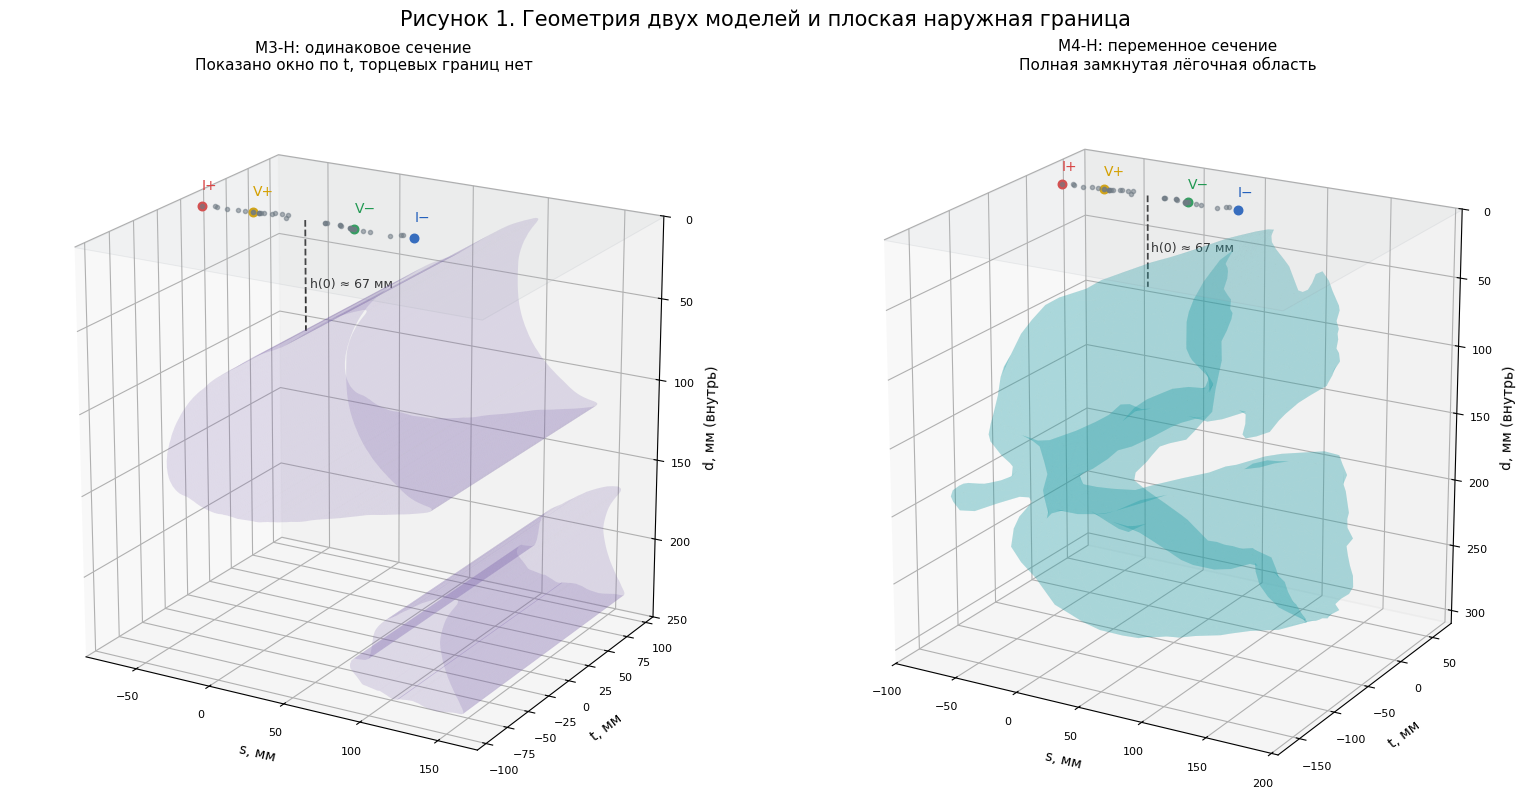

In [2]:
show(1)

**Рисунок 1. Геометрия М3-H и М4-H.** Полупрозрачная серая плоскость — кожа $d=0$; цветная область — лёгкое. Малые серые точки показывают проекции всех контактов, цветом выделены четыре электрода сборки 140 мм: токовые $I+,I-$ и измерительные $V+,V-$. Пунктир показывает направленную центральную глубину $h(0)$.

**Как анализировать.** Слева одинаковый контур повторяется по $t$; справа контур изменяется и замыкается в объёме. Сравнивать нужно не только ближайшую границу, но и заполнение лёгким пространства за ней. Рисунок объясняет отличие геометрий, но не является картой чувствительности и не доказывает, что дальняя часть включения несущественна.

**Вывод и переход.** Мы сохранили два разных описания криволинейного лёгкого и одинаковую плоскую кожу. Следующий вопрос — достаточно ли точно численно решается каждая из этих задач. Без такого контроля расхождение с КТ/FEM нельзя уверенно относить к геометрическому упрощению.


## 4. Численные проверки перед обратной задачей

Проверены однородный предел, взаимность, производные по контрасту и задача о сфере с известным аналитическим решением. Для сферы на 1920 треугольниках максимальная относительная ошибка в проверенном наборе составила 0,0471%; конечные разности согласовались с аналитическими производными приблизительно до $8\cdot10^{-10}$ по относительной норме. Независимо проверены ядро Фурье и цилиндрическая задача.

Численная устойчивость решения на основной геометрии проверена отдельно для импеданса и чувствительности к $\rho_2$. Малое изменение $Z$ ещё не гарантирует малое изменение его производной. На рисунке 2 сравниваются дискретизации при $q=4$ и $q=12$. Второй контраст расширяет численный контроль и не служит самостоятельной физиологической оценкой.


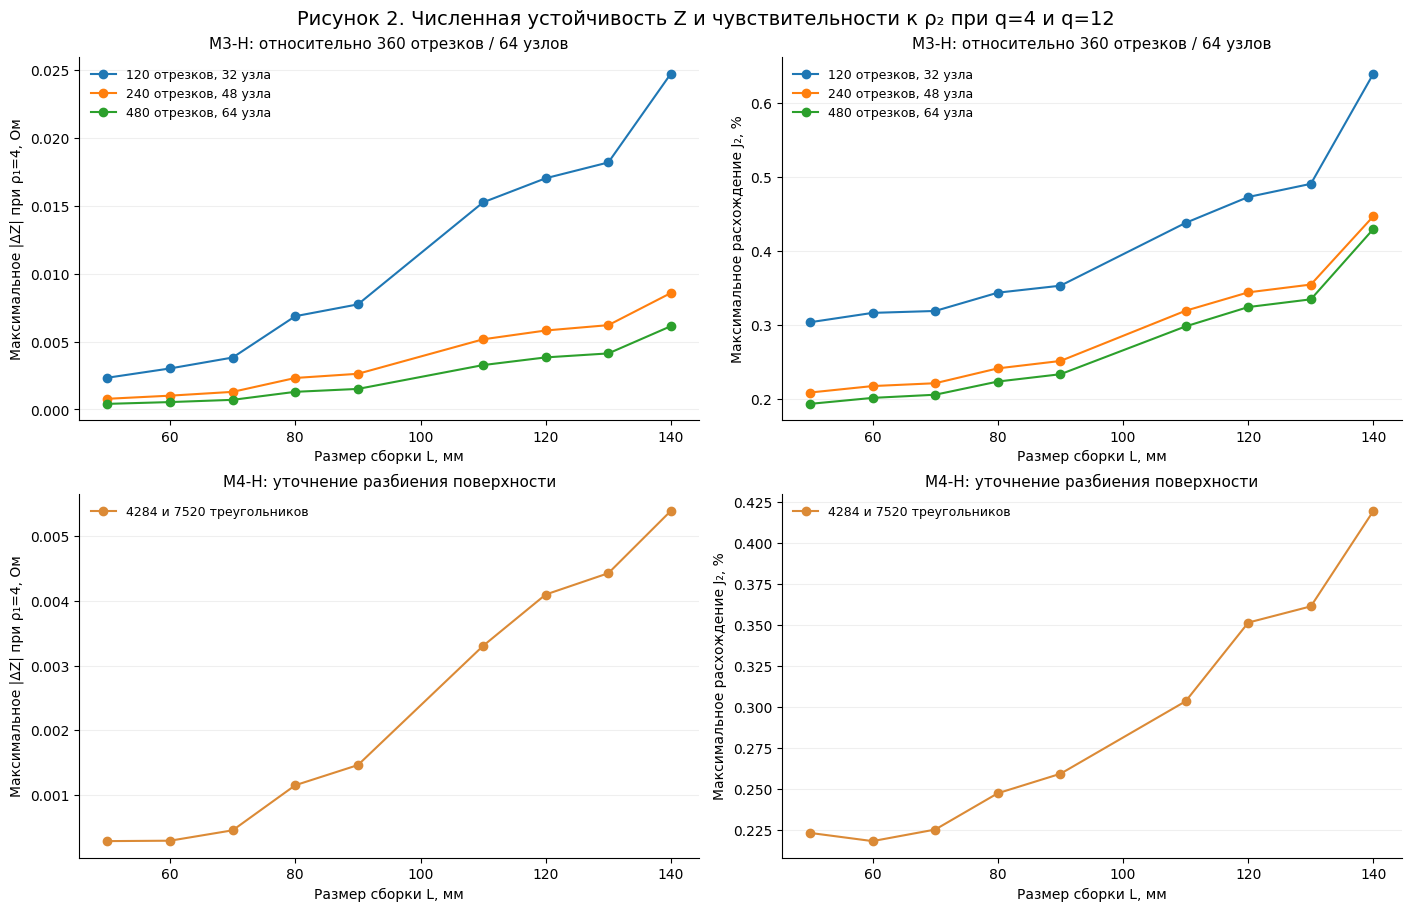

In [3]:
show(2)

**Рисунок 2. Изменение результата при уточнении дискретизации.** Верхний ряд относится к М3-H, нижний — к М4-H. Слева показано максимальное по двум контрастам абсолютное расхождение $Z$ при $\rho_1=4$ Ом·м; справа — относительное расхождение столбца чувствительности к $\rho_2$. По горизонтали — размер сборки.

**Результат.** Для М3-H переход от 360 к 480 отрезкам при 64 узлах Фурье меняет $Z$ не более чем на 0,00614 Ом, а чувствительность — примерно на 0,431%. Отдельная замена 32 узлов Фурье на 64 при неизменных 360 отрезках даёт изменение $Z$ около $1,53\cdot10^{-9}$ Ом. Для М4-H переход от 4284 к 7520 треугольникам меняет $Z$ не более чем на 0,00540 Ом, чувствительность — примерно на 0,420%.

**Ограничения.** Это оценки различий проверенных дискретизаций, а не доказанная верхняя граница ошибки для любых геометрий и сопротивлений. Масштаб преобразования Фурье, квадратуры, предельные геометрии и непрерывный предел конечных контактов требуют отдельных исследований. Первоначальная грубо прореженная трёхмерная поверхность М3-H не прошла контроль поля и взаимности; её результаты исключены из основного сравнения и сохранены как отрицательный контроль.

**Переход.** После этих проверок полезно убрать контраст лёгкого совсем. Если отличие от КТ/FEM останется при $\rho_1=\rho_2$, его нельзя объяснять только формой границы лёгкого.


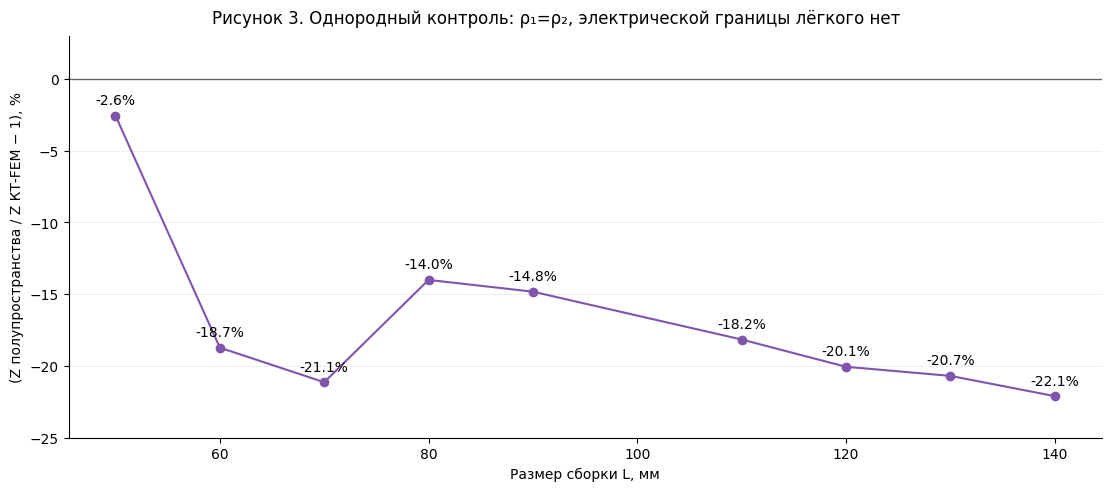

In [4]:
show(3)

**Рисунок 3. Однородное полупространство относительно однородного тела по КТ.** При $q=1$ граница лёгкого электрически исчезает: М3-H, М4-H и аналитическая модель с проецированными контактами должны давать один результат. По вертикали показано $100(Z_H/Z_{\rm CT}-1)$.

**Результат и смысл.** Полупространство даёт меньший импеданс: расхождение составляет от −2,57% до −22,11% в зависимости от размера. Следовательно, часть несоответствия присутствует ещё до введения лёгочного контраста. Возможные составляющие — замена наружной формы тела, проекция координат и численная реализация точечных контактов в объёмной сетке. Этот опыт не разделяет их вклады.

**Ограничения и переход.** Обе стороны сравнения используют точечные PEM-электроды; конечная площадь контакта не является различием данного теста. Нельзя автоматически приписать всё расхождение одной кривизне кожи или исправить его постоянным множителем: величина зависит от размера. Теперь проверим, как оно переносится в оценки двух сопротивлений.


## 5. Точность обратного восстановления в рабочих диапазонах

Синтетические данные получены полной КТ/FEM-моделью на сетке 153 415 узлов и 721 943 тетраэдров. Проверены все 16 сочетаний
$$\rho_1^\ast\in\{2,4,6,8\},\qquad \rho_2^\ast\in\{10,14,18,22\}\quad\text{Ом·м},$$
где $\rho_1^\ast,\rho_2^\ast$ — заданные сопротивления фона и лёгкого; их попарные сочетания образуют 16 состояний.

Для каждого сочетания все девять импедансов совместно используются в ограниченной подгонке:
$$\widehat{\boldsymbol\rho}
=\arg\min_{\boldsymbol\rho\in\mathcal B}
\sum_{L}\big[Z_L^{\rm model}(\boldsymbol\rho)-Z_L^{\rm CT}(\boldsymbol\rho^\ast)\big]^2,$$
где $\widehat{\boldsymbol\rho}$ — искомая пара, $\boldsymbol\rho^\ast$ — заданная пара, $\mathcal B$ — рабочие границы после таблиц 1–2, $L$ — размер сборки, $Z_L^{\rm model}$ — импеданс проверяемой модели, $Z_L^{\rm CT}$ — КТ/FEM-референс.

Вес каждого остатка в омах одинаков. Это заданное правило сравнения, а не установленная модель шума реальных измерений. Геометрия при подгонке фиксирована; неизвестны только $\rho_1,\rho_2$.

Для многократных вызовов используется зависимость $Z=\rho_1f(q)$ и интерполяция заранее рассчитанной библиотеки по $\log q$, с сохранёнными производными и контрольными промежуточными точками. Для FEM это также позволяет ускорять инверсию без нового объёмного решения при каждом шаге оптимизатора.


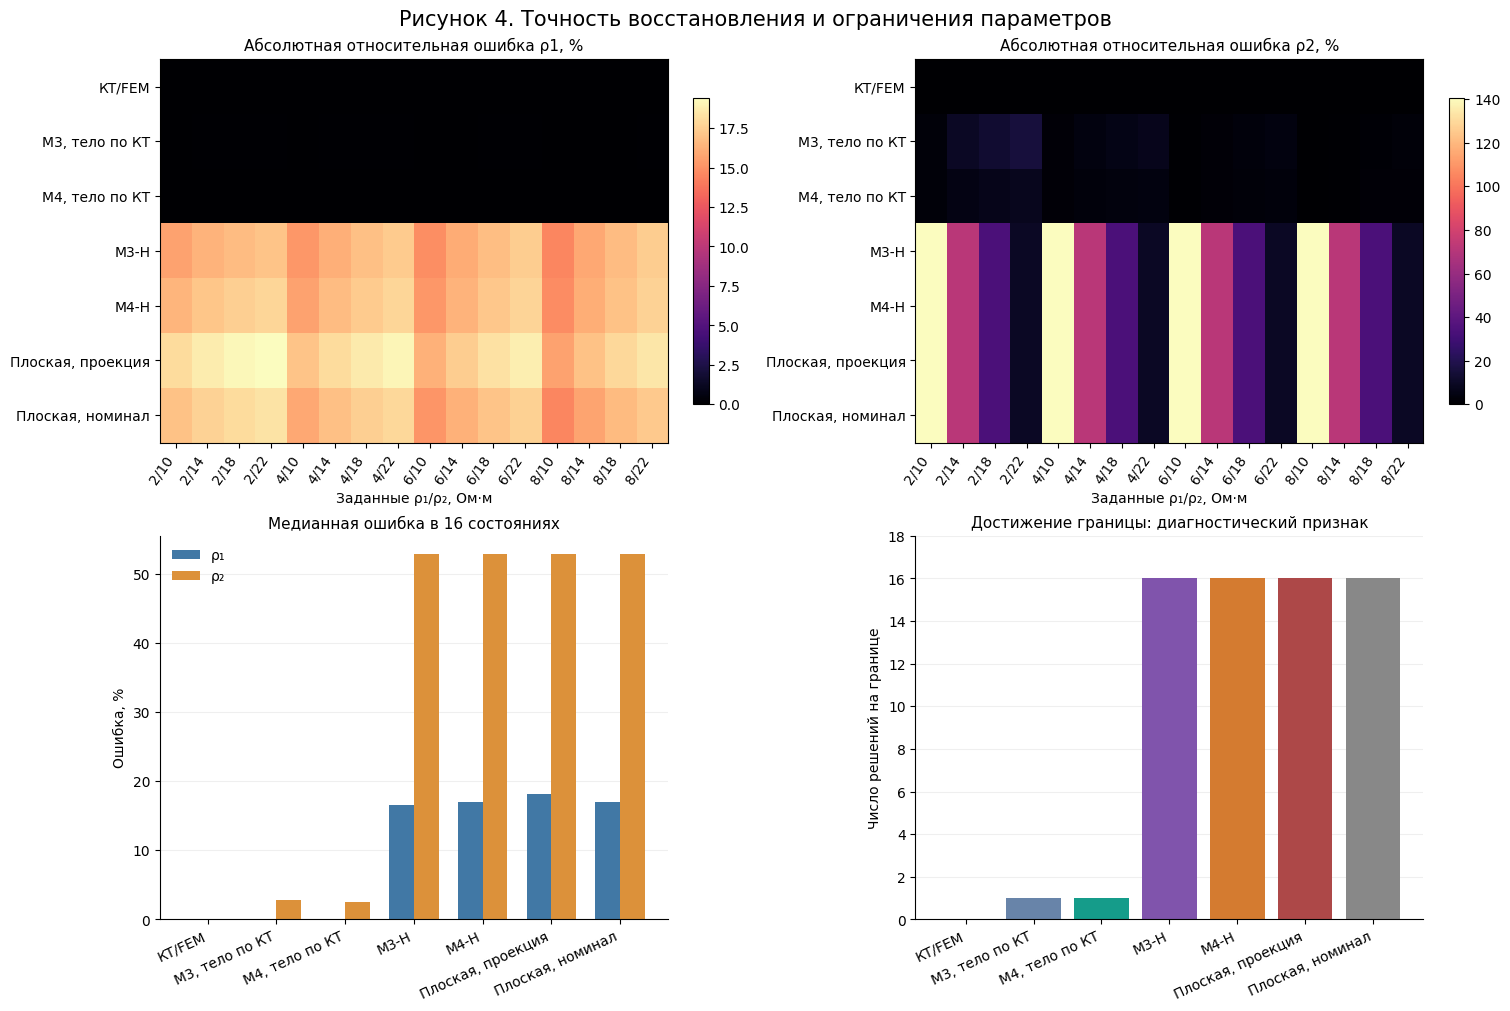

In [5]:
show(4)

**Рисунок 4. Ошибки восстановления и достижение границ.** В верхнем ряду каждая колонка соответствует известной паре $\rho_1^\ast/\rho_2^\ast$, каждая строка — модели; цвет показывает абсолютную относительную ошибку. Внизу слева — медианы ошибок, справа — число решений, в которых хотя бы одно из двух сопротивлений достигло своей нижней или верхней допустимой границы.

**Результат.** М3-H, М4-H и оба плоских варианта дают верхнюю допустимую оценку $\rho_2$ во всех 16 случаях. Для М3-H и М4-H медианная ошибка $\rho_2$ одинакова — 52,85%, максимальная — 140,74%. Медианные ошибки $\rho_1$ равны соответственно 16,54% и 17,05%. Одинаковая оценка лёгочного сопротивления здесь объясняется ограничением, а не одинаковой точностью прямых моделей.

У М3 внутри тела по КТ медианная ошибка $\rho_2$ составляет 2,75%, максимальная — 15,49%; у М4 внутри тела по КТ — 2,49% и 7,86%. В обеих этих сериях по одному решению достигло границы. По данному критерию из двух сокращений внутри тела предпочтительна М4, но это ещё не универсальный победитель: рассмотрено одно место у одного испытуемого, а допустимая ошибка конечной методики ещё не установлена.

Почти нулевая ошибка строки «КТ/FEM» — контроль восстановления собственных синтетических данных. Она подтверждает согласованность интерполяции и оптимизации, но не физическую истинность FEM. Нулевая ошибка плоской модели здесь не задаётся.

**Переход.** Для дыхательной и пульсовой задачи важны не только уровни $Z$, но и производные по тканевым параметрам. Хорошая подгонка базового импеданса может получаться при неверном распределении вклада между тканями; это проверяется далее.


## 6. От базовых сопротивлений к пульсовым изменениям

После восстановления базового состояния для каждого размера вычисляется якобиан
$$J_{Lj}=\frac{\partial Z_L}{\partial\rho_j},$$
где $J_{Lj}$ — чувствительность импеданса $Z_L$ сборки размера $L$ к сопротивлению $\rho_j$ области $j$.

Для модели $Z=\rho_1f(q)$ и $f'=\partial f/\partial\log q$:
$$J_{L1}=f_L-f'_L,\qquad J_{L2}=\frac{f'_L}{q},$$
где $f_L$ — передаточный коэффициент, $f'_L$ — его производная по $\log q$, $q=\rho_2/\rho_1$, а индексы 1 и 2 относятся к фону и лёгкому.

Производные берутся при конкретной геометрии и конкретном базовом состоянии. Ошибка базовых $\rho$ поэтому переносится в последующее пульсовое восстановление.

При малых пульсовых изменениях и фиксированной геометрии
$$\delta Z_L(\tau)\simeq J_{L1}\delta\rho_1(\tau)+J_{L2}\delta\rho_2(\tau),$$
где $\delta Z_L$ — пульсовое отклонение импеданса, $\delta\rho_j$ — приращение сопротивления области $j$, $J_{Lj}$ — базовая чувствительность, $\tau$ — время внутри сердечного цикла.

Малые $\delta\rho_j$ могут иметь оба знака. Физиологические ограничения относятся к полным значениям $\rho_j+\delta\rho_j$, а не требуют положительности самого приращения. Если геометрия меняется, добавляются члены $J_h\delta h$ и производные по положению контактов. Их исключение является отдельным допущением.

Для системы из нескольких размеров можно решать взвешенную линейную задачу
$$\widehat{\delta\boldsymbol\rho}
=\arg\min_{\delta\boldsymbol\rho}
\|W^{1/2}(J\delta\boldsymbol\rho-\delta\mathbf Z)\|_2^2,$$
где $\widehat{\delta\boldsymbol\rho}$ — вектор двух оцениваемых приращений, $\delta\mathbf Z$ — отклики сборок, $J$ — матрица чувствительности, $W$ — матрица весов, $\|\cdot\|_2$ — евклидова норма.

В данном вычислительном опыте $W=I$, где $I$ — единичная матрица. В реальных данных веса должны учитывать качество и неопределённость каждого сигнала; гауссовость распределения ошибок и их ковариацию нужно обосновать отдельно.

Высокая чувствительность к $\rho_2$ сама по себе недостаточна. Если столбцы $J_1,J_2$ почти пропорциональны, изменения двух тканей дают похожие наборы импедансов и плохо разделяются. Число обусловленности $\kappa_2=\sigma_{\max}/\sigma_{\min}$ — отношение наибольшего и наименьшего сингулярных значений рассматриваемой матрицы чувствительности. Оно характеризует усиление ошибок при обращении; оно зависит от масштабирования параметров и весов измерений. Для сравнения протоколов нужно заранее фиксировать эту нормировку, например исследовать безразмерные параметры $\log\rho_j$. Параметр с малой чувствительностью и пара почти совпадающих столбцов — разные причины неустойчивости.

**Независимый нелинейный тест.** При известном базовом состоянии $(4;16)$ Ом·м заново решён полный FEM для приращений $(0{,}0004;0)$, $(0;0{,}016)$, $(0{,}0004;0{,}016)$, отрицательного совместного приращения и увеличенного в 10 раз совместного приращения. Эти числа выбраны для математической проверки, а не выданы за измеренные пульсовые амплитуды.


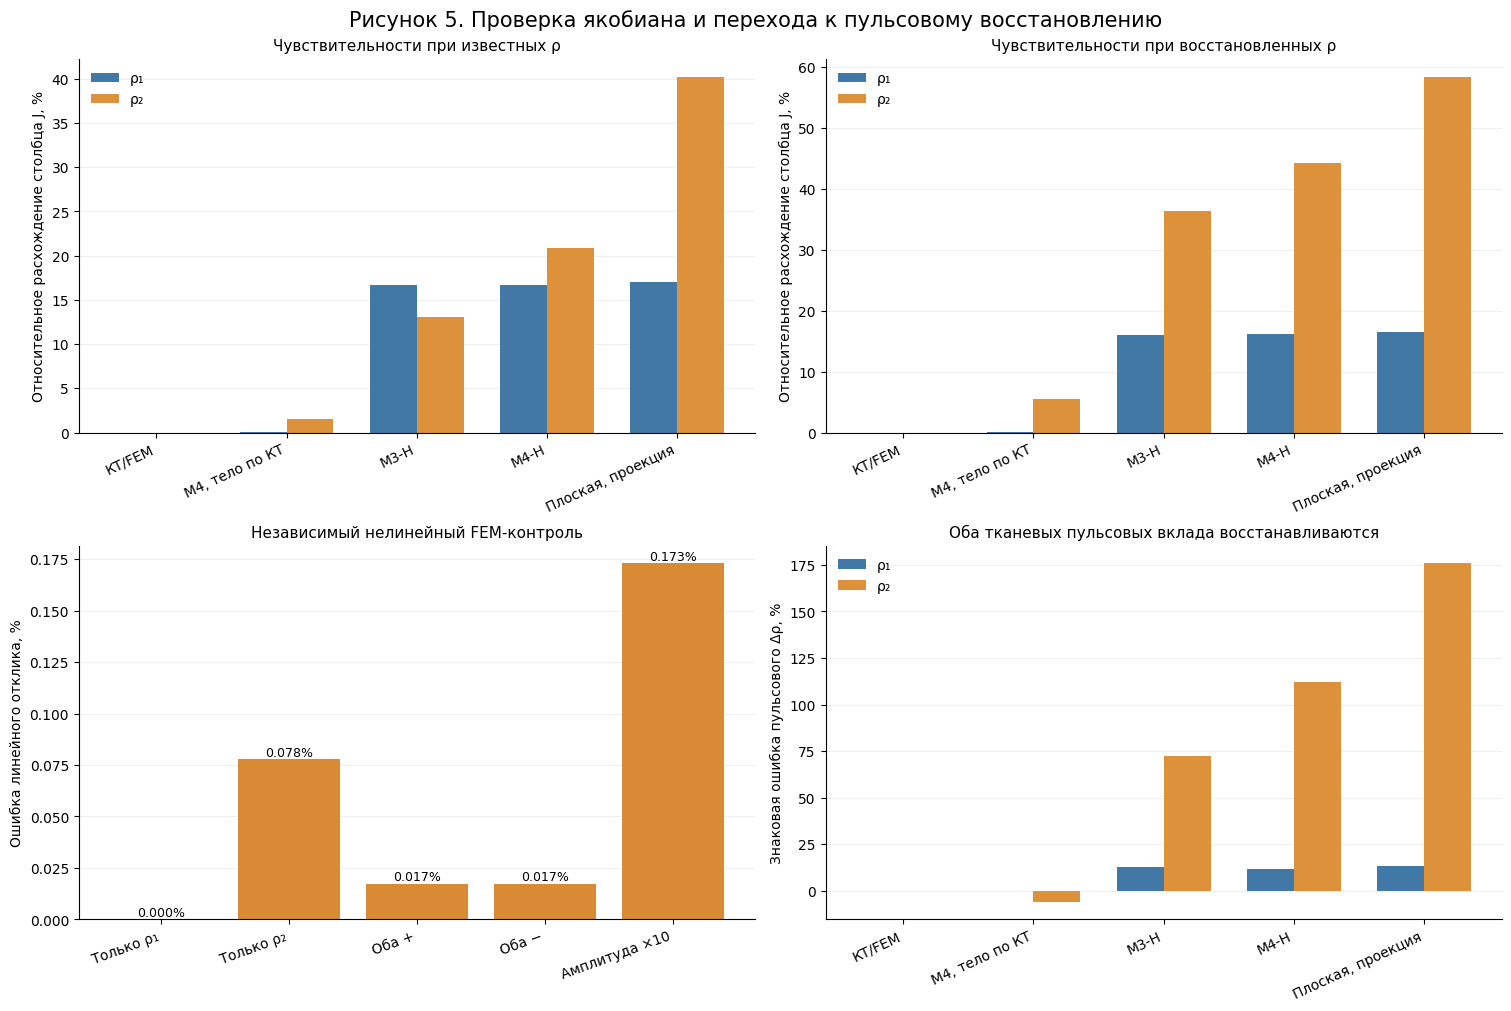

In [6]:
show(5)

**Рисунок 5. Чувствительность и пульсовое восстановление.** Сверху сравниваются столбцы якобиана с КТ/FEM: слева при известных сопротивлениях, справа при восстановленных. Каждый столбец графика — медианная относительная норма расхождения по 16 состояниям. Снизу слева проверяется линеаризация на новых нелинейных FEM-расчётах; снизу справа показана ошибка восстановления обоих ненулевых пульсовых приращений из полного нелинейного отклика.

Для нижней левой панели использована норма
$$\varepsilon_{\rm lin}=100\,
\frac{\max_L|\delta Z_L^{\rm FEM}-(J\delta\boldsymbol\rho)_L|}
{\max_L|\delta Z_L^{\rm FEM}|},$$
где $\varepsilon_{\rm lin}$ — ошибка в процентах, $\delta Z_L^{\rm FEM}$ — разность полных FEM-решений, $J\delta\boldsymbol\rho$ — линейный прогноз; максимум берётся по девяти размерам $L$.

Она не является максимумом относительных ошибок отдельных каналов и не расходится из-за почти нулевого отклика одного размера.

**Результат.** Медианное расхождение чувствительности к $\rho_2$ при известных $\rho$ составляет около 13% у М3-H и 21% у М4-H; после подстановки ошибочно восстановленного базового состояния оно возрастает примерно до 36% и 44%. У М4 внутри тела по КТ соответствующие величины — около 1,5% и 5,5%.

Для малого положительного совместного приращения нелинейный контроль даёт $\varepsilon_{\rm lin}\approx0{,}0174\%$; даже в десятикратном контрольном случае — около 0,173%. В этих условиях ошибка линейного приближения мала относительно рассчитанного пульсового отклика. Ошибка сокращённой геометрии и базовой оценки может оказаться существенно больше ошибки линеаризации.

**Ограничения и переход.** Тест не подтверждает качество экспериментальных пульсовых сигналов и не исключает движения тканей. Чтобы решить, можно ли уменьшить число неизвестных, далее нужно проверить последствия конкретных допущений: постоянства $h$, постоянства дыхательного $\rho_1$ и отсутствия мягкотканного пульсового вклада.


## 7. Ошибки положения и проверка сокращения числа неизвестных

Дыхательный контраст определяется как $\Delta Z=Z_B-Z_A$, а базовое состояние A задаётся парой $(4;16)$ Ом·м. Для глубокого дыхательного изменения состояние B имеет $(4;12)$, для обычного — $(4;14{,}4)$ Ом·м. Это сценарии, а не измеренные сопротивления вдоха и выдоха.

Проверяются отдельно: неизменное $h$; изменение $h$ между A и B на −2 или +2 мм при глубоком дыхании; на −1 или +1 мм при обычном; увеличение $\rho_1$ в B на 1%. Заданные автором 2 и 1 мм означают предел **между состояниями**, а не две встречные амплитуды, которые нужно складывать. Знаки обозначают разные альтернативные опыты. Сохранённое изменение геометрии — модельное смещение границы; оно не является зарегистрированным движением лёгкого по паре дыхательных КТ.

В отдельном свежем FEM-опыте все контакты смещались на желаемые ±2 мм по $s$ или $t$ и затем выбирался ближайший граничный узел. Из 144 смещаемых контактов 40 остались в исходном узле; максимальное фактическое перемещение составило 3,74 мм. Поэтому это тест дискретного переноса точечных электродов, а не гладкая производная по координате.

Дополнительно каждый из девяти импедансов поочерёдно изменялся на ±1% при неизменных остальных. Это 18 детерминированных возмущений одного набора, а не статистическая оценка совокупной экспериментальной погрешности.


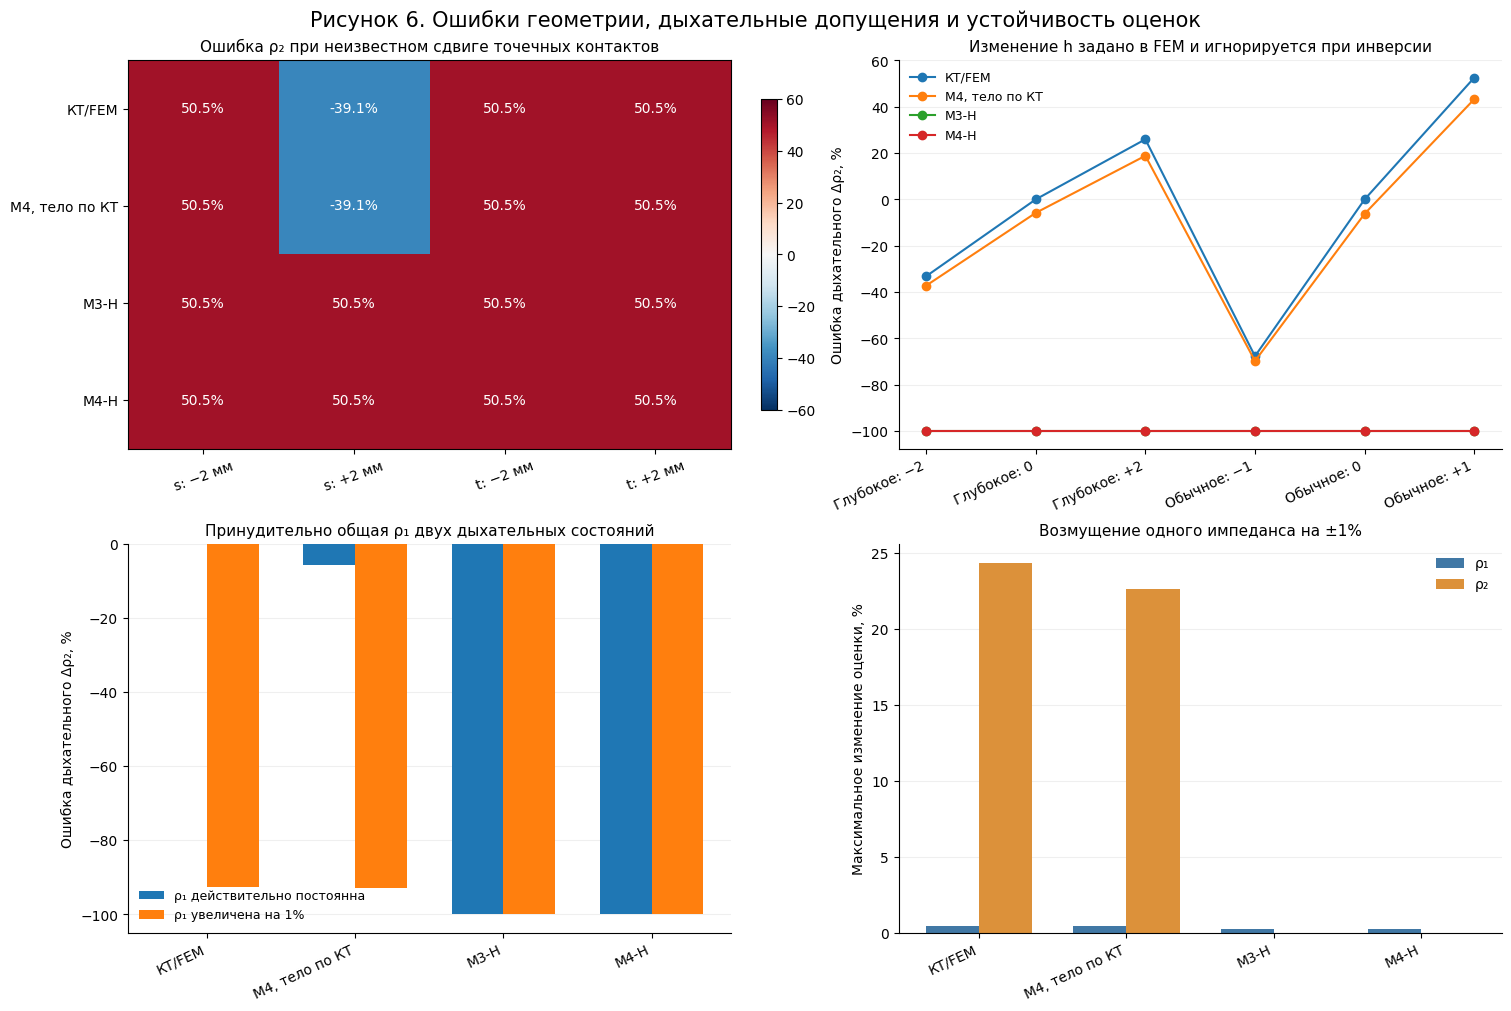

In [7]:
show(6)

**Рисунок 6. Четыре проверки устойчивости и допущений.** Слева сверху показана ошибка $\rho_2$ при переносе контактов, который не учитывается в обратной задаче; справа сверху — ошибка дыхательного $\Delta\rho_2$, когда заданное в FEM изменение $h$ игнорируется. Слева снизу в двух дыхательных состояниях принудительно восстанавливается общая $\rho_1$; сравниваются случаи, когда она действительно постоянна и когда изменилась на 1%. Справа снизу показано максимальное изменение оценок при одиночных возмущениях импеданса.

**Количественные результаты.** Даже для КТ-референса игнорирование заданного изменения $h$ на −2 мм даёт ошибку дыхательного $\Delta\rho_2$ около −33,2%, а на +2 мм — около +25,9%. Игнорирование увеличения $\rho_1$ всего на 1% при требовании общей $\rho_1$ даёт ошибку $\Delta\rho_2$ около −92,6%. Это контрпримеры, показывающие, что малость изменения одного входа не гарантирует малости ошибки восстанавливаемого другого параметра.

Для дискретного переноса контактов ошибки $\rho_2$ у КТ-референса находятся примерно от −39,1% до +50,5%. Их нельзя переносить на непрерывное смещение без проверки контактной модели. Нулевая изменчивость оценки $\rho_2$ у полупространственных моделей в отдельных тестах объясняется достижением верхней границы и не является устойчивостью.

**Дополнительный пульсовой контрпример, сохранённый в таблице сценариев.** В состоянии B $(4;12)$ заданы $\delta\rho_1=0{,}0004$ и $\delta\rho_2=0{,}012$ Ом·м. Если при обратном расчёте даже с правильным КТ-якобианом принять $\delta\rho_1=0$, ошибка лёгочного пульсового приращения составляет **+247,55%**. Исключённый мягкотканный вклад частично переносится в оценку лёгочного параметра. Это синтетический пример, а не утверждение о такой ошибке во всех реальных записях.

**Вывод и переход.** Постоянство базовой $\rho_1$ при дыхании, постоянство $h$ и нулевой мягкотканный пульс — три разных допущения. Ни одно не следует из другого. Их можно принимать только после оценки вносимой ошибки. После проверки точности остаётся практический вопрос: даёт ли сокращение геометрии необходимый выигрыш времени?


## 8. Время расчёта: подготовка, прямое решение и библиотека

Сравнение времени разделено на три операции: подготовку геометрического оператора; новое решение для девяти $Z$ и обоих столбцов якобиана; обращения к готовой интерполяционной библиотеке. Для BEM выполнено пять повторов после прогрева, для нового FEM-контроля — три. В обоих случаях линейная алгебра вычислялась с ограничением до шести потоков BLAS.

В измеренное время прямого решения входит новая факторизация матрицы при заданных сопротивлениях. Геометрические матрицы уже подготовлены. Для FEM известно время загрузки и сборки проводящей матрицы из сохранённых блоков, но время исходного построения сетки и этих блоков в данном опыте не измерялось. Поэтому здесь нет полного сравнения стоимости подготовки нового пациента от КТ до ответа.


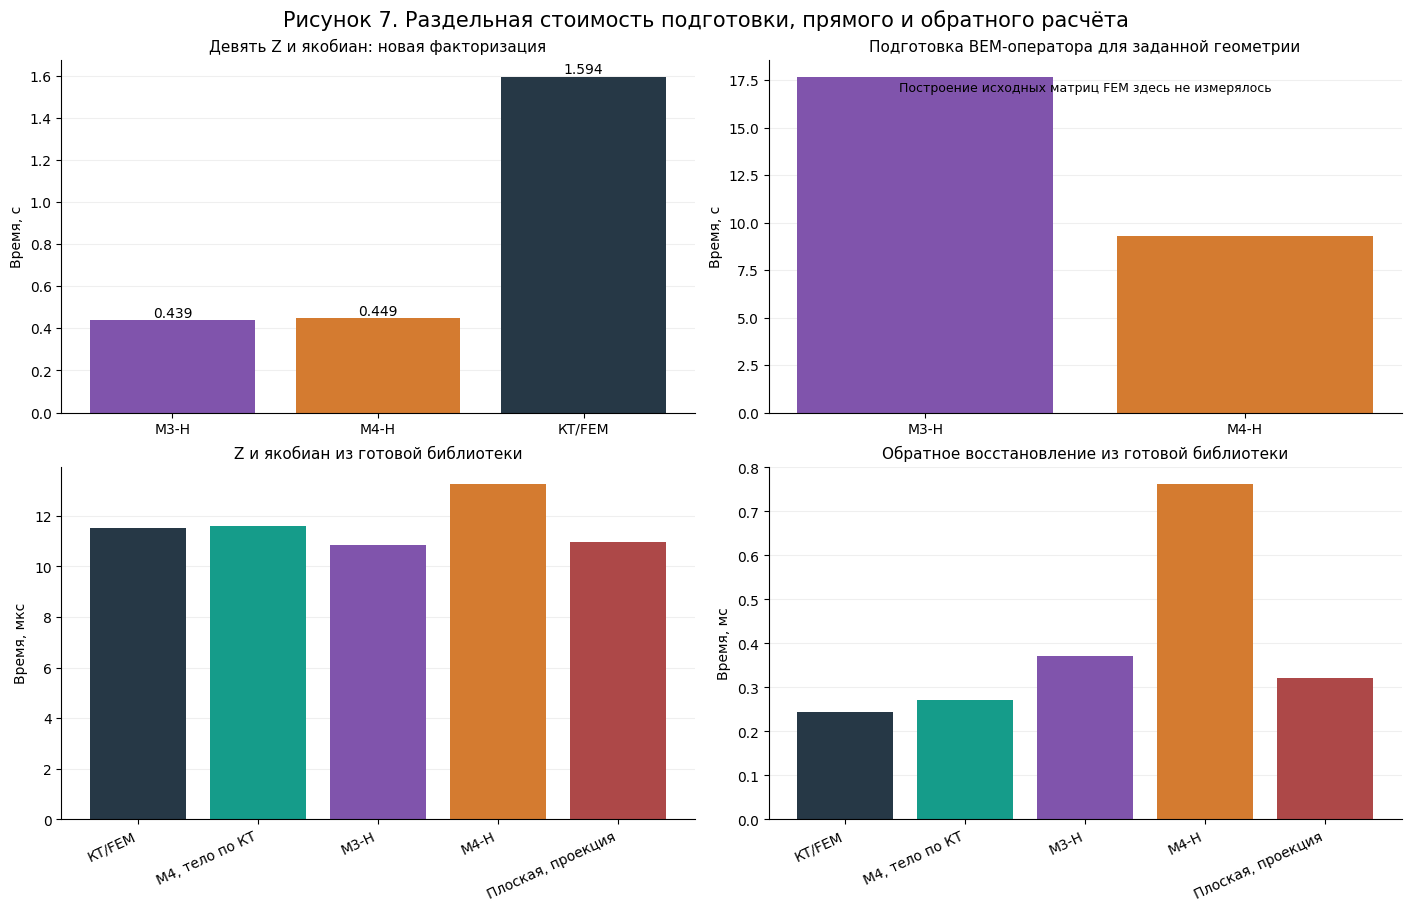

In [8]:
show(7)

**Рисунок 7. Время подготовки, прямого решения и обратного восстановления.** Слева сверху — медианное время нового прямого решения и якобиана; справа сверху — подготовка BEM-оператора. Внизу показаны медианы обращений к готовой библиотеке: $Z$ с якобианом в микросекундах и обратная подгонка в миллисекундах. Малое время подгонки модели, достигшей границы параметра, само по себе не является преимуществом.

**Результат.** М3-H требует около 0,439 с, М4-H — 0,449 с, КТ/FEM — 1,594 с для девяти импедансов и якобиана. Выигрыш основного BEM-решения в этом опыте составляет примерно 3,6 раза, но при существенно худшем восстановлении $\rho_2$. Подготовка BEM занимает около 17,7 с и 9,27 с соответственно. При уточнении поверхности М4-H до 7520 треугольников прямой расчёт занимает около 2 с, то есть уже сопоставим с рассматриваемым FEM.

Готовые библиотеки всех моделей, включая КТ/FEM, дают $Z$ с якобианом примерно за 10–13 мкс. Медианное время обратного восстановления составляет около 0,244 мс для КТ/FEM, 0,272 мс для М4 внутри тела, 0,372 мс для М3-H и 0,763 мс для М4-H.

**Практический вывод.** Пока наиболее обоснованный быстрый вариант — использовать FEM для подготовки индивидуальной библиотеки и затем выполнять многократное обратное восстановление по ней. Полупространственные модели пока не дают преимущества одновременно по точности и скорости. Это не исключает будущую удачную редукцию при другом месте монтажа или более точном описании наружной границы.

**Переход.** Основная серия использует точечные электроды. Прежде чем обсуждать физический перенос на реальные площадки, нужен отдельный расчёт полной электродной модели.


## 9. Что именно рассчитано с конечными электродами

В дополнительном контроле решена **полная электродная модель CEM** [4] для М4-H при одной известной паре $(\rho_1,\rho_2)=(4;16)$ Ом·м. Контакты заменены плоскими круглыми площадками: центр каждого исходного CEM-контакта спроецирован на $d=0$, площадь **каждой** исходной площадки сохранена. Это не означает одинаковую площадь всех контактов. Исходные CEM-центроиды отличаются от PEM-узлов основной серии.

На каждом электроде выполняются условия
$$u+z_cj_n=U_e,\qquad \int_{e}j_n\,dS=I_e,$$
где $j_n$ — плотность тока от электрода в ткань, $I_e$ — его интеграл по площадке $e$, $z_c=0{,}0001591549431$ Ом·м² — заданное удельное контактное сопротивление, $U_e$ — постоянный потенциал металлической площадки. Для измерительного электрода $I_e=0$, но локальная плотность тока под ним может быть ненулевой. Решается дискретная CEM-система для всех четырёх контактов, а не задача с заранее равномерной плотностью тока.

Проверены 6, 24 и 54 треугольные панели на электрод. Результаты сравниваются с сохранённым КТ/FEM-CEM при тех же сопротивлениях, исходных площадках и том же $z_c$. Изменение формы и рельефа контакта входит в расхождение моделей.


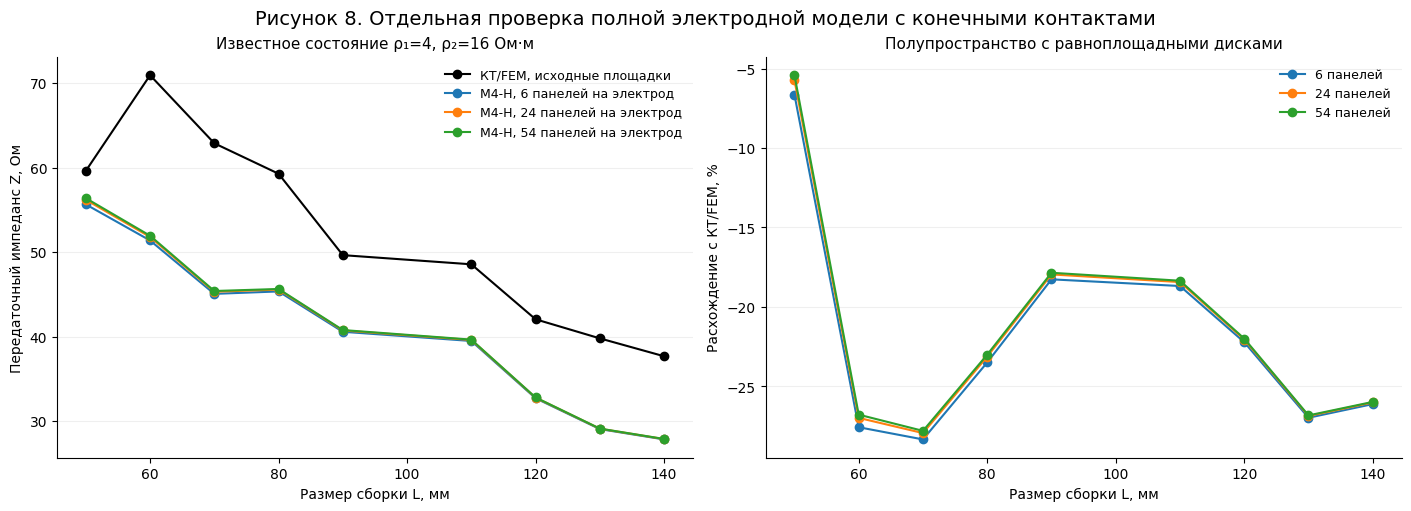

In [9]:
show(8)

**Рисунок 8. Прямой CEM-контроль для девяти размеров.** Слева — абсолютные импедансы КТ/FEM с исходными площадками и М4-H с равноплощадными дисками при трёх разбиениях. Справа — относительное расхождение каждого варианта М4-H с КТ/FEM.

**Результат.** Переход от 24 к 54 панелям меняет $Z$ не более чем на 0,337%. При 54 панелях расхождение М4-H с КТ/FEM остаётся примерно от −5,42% до −27,79%. Следовательно, в этом примере введение конечной площади контакта не устраняет систематическое отличие полупространства.

**Ограничения и вывод.** Это один прямой контроль, а не новая серия восстановления 16 пар параметров. Для М3-H конечные электроды здесь не рассчитывались. Площадь и контактное сопротивление сохранены, но форма, рельеф и центры в трёхмерном пространстве изменены; данные не позволяют выделить один из этих факторов как единственную причину ошибки.


## 10. Что принять в дальнейшую методику

### 10.1. Последовательность от индивидуальной КТ к выбору пары

Предложенный порядок исследования принимается в следующем виде:

1. Определить кандидатное место монтажа на КТ и зафиксировать его анатомические ориентиры, ориентацию и неопределённость установки.
2. Получить профиль кожа–лёгкое и полное окружение сборки. Одного значения $h$ и одной ближайшей поверхности недостаточно, если луч повторно пересекает лёгкое.
3. **Выбрать и валидировать правило сведения** этой геометрии к эффективным параметрам каждой сборки. Оно должно работать на разных сопротивлениях и размерах, а не подбираться по тому же набору импедансов без независимой проверки.
4. Раздельно оценивать абсолютный уровень и парный дыхательный контраст. Контраст может уменьшать постоянную составляющую ошибки, но не устраняет автоматически влияние изменяющихся $h$, $\rho_1$ и положения.
5. Проверить сценарии изменения $h$ и $\rho_1$, погрешности установки и восстановления; сравнить сокращённую модель с КТ/FEM.
6. Только после этого выбирать минимальный набор и пару сборок по точности и разделимости тканевых вкладов.

При построении эффективного $h_L$ через чувствительность нужно помнить: тетраполярное ядро $\nabla u_I\cdot\nabla u_V$ знакопеременно. Использование его модуля или квадрата как положительных весов — отдельный выбор, подлежащий проверке. Кроме того, поля зависят от неизвестных $\rho_1,\rho_2$, поэтому такое усреднение не является чисто геометрическим измерением. Нужно проверить устойчивость $h_{{\rm eff},L}(q)$ или ввести согласованное итерационное правило.

Нельзя независимо восстанавливать произвольное $h_L$ для каждой из $n$ сборок по $n$ импедансам одновременно с двумя сопротивлениями: получается $n+2$ неизвестных. Нужна связанная геометрическая параметризация, дополнительные данные или проверяемые ограничения. Протокол этого перехода изложен в сопроводительном документе.

Межсубъектный поиск места здесь **не выполнен**. Его будущая цель сохранена: повторяемое анатомическое место с достаточно простой геометрией, предсказуемой кривизной, различающимися чувствительностями выбранных размеров и малым вкладом сердца и других органов. Большое расстояние до органа — предварительный анатомический признак; количественный вклад проверяется по полю чувствительности. Геометрическая близость к плоской двухслойной задаче не гарантирует хорошего восстановления $\rho_2$, если ток почти не чувствителен к лёгкому.

### 10.2. Как перейти к экспериментальным пульсовым параметрам

Для каждого принятого дыхательного состояния сначала восстанавливаются базовые сопротивления и вычисляется соответствующий якобиан. Затем из экспериментальных записей выделяются качественные сердечные циклы, согласуются по ЭКГ с учётом физиологической задержки и оцениваются средние формы $\delta Z_L(\tau)$ вместе с их изменчивостью. ЭКГ задаёт время, но сама по себе не разделяет тканевые источники.

Поскольку разные размеры записывались последовательно, совместная инверсия их пульсовых форм требует отдельно принятого допущения о сопоставимости состояния. Нельзя обращаться с ними как с девятью одновременно измеренными каналами. После такого согласования решается двухпараметрическая задача раздела 6. Восстановленные приращения подставляются обратно в прямую модель; анализируются остатки, устойчивость к выбору циклов и размерам, а также возможный геометрический вклад.

Основная версия должна сохранять оба пульсовых параметра. На экспериментальных данных вариант $\delta\rho_1=0$ следует проверять как сокращение полной двухпараметрической версии. Постоянство базовой $\rho_1$ между вдохом и выдохом не означает нулевого мягкотканного пульса.

Реальное пульсовое восстановление в 20.17 не выполнено. Для него требуется адресный выбор пригодных интервалов и каналов в экспериментах 2–3 с принятыми дыхательными и ЭКГ-метками. Это не утверждение о непригодности всей серии. Синтетический нелинейный тест уже проверяет математический переход; качество конкретных записей и допустимость объединения остаются самостоятельными условиями.

### 10.3. Итог вычислительного этапа

Текущие М3-H и М4-H пока не следует использовать для количественного восстановления $\rho_2$ в положении C01. Более точное из проверенных сокращений — переменное сечение лёгкого с сохранением тела по КТ; для быстрых повторных расчётов полезна заранее подготовленная FEM-библиотека. Перед новым усложнением формы лёгкого целесообразно раздельно исследовать наружную границу и перенос контактов, поскольку расхождение возникает уже в однородном теле.

Ни минимальная пара сборок, ни универсальное место установки, ни восстановление сердечных функций по этим результатам не объявляются установленными.


## 11. Научные источники

1. Stenroos M. *Integral equations and boundary-element solution for static potential in a general piece-wise homogeneous volume conductor*. Physics in Medicine and Biology. 2016;61:N606–N617. [DOI: 10.1088/0031-9155/61/22/N606](https://doi.org/10.1088/0031-9155/61/22/N606), [авторский текст](https://arxiv.org/pdf/1605.00923). Источник общей интегральной постановки; его дискретизация не тождественна нашей.
2. 권오일, 조인기. *경계요소법에 의한 2.5 차원 전기비저항탐사 모델링* [Моделирование электрического сопротивления методом граничных элементов в постановке 2,5D]. 2001;38(3):163–168. [Первичная страница журнала](https://www.jksmer.or.kr/articles/article/DO4Q/). Пример сочетания преобразования Фурье и BEM; русское пояснение названия дано для читателя.
3. Pan K., Tang J. *2.5-D and 3-D DC resistivity modelling using an extrapolation cascadic multigrid method*. Geophysical Journal International. 2014;197:1459–1470. [DOI: 10.1093/gji/ggu094](https://academic.oup.com/gji/article/197/3/1459/657688). Используется для частичного преобразования Фурье; численный решатель статьи основан на FEM и не доказывает преимущество нашего BEM по скорости.
4. Somersalo E., Cheney M., Isaacson D. *Existence and Uniqueness for Electrode Models for Electric Current Computed Tomography*. SIAM Journal on Applied Mathematics. 1992;52:1023–1040. [DOI: 10.1137/0152060](https://doi.org/10.1137/0152060). Математическая постановка полной электродной модели.
5. IT'IS Foundation. *Tissue Properties Database, version 5.0*. [База свойств тканей](https://itis.swiss/virtual-population/tissue-properties/downloads/database-v5-0). Источник литературных ориентиров, использованных в 20.14. Эффективные параметры текущего двухтканного объединения не являются непосредственно измеренными табличными свойствами одной ткани.

Эти источники обосновывают математические направления и исходные ориентиры. Доказательства точности именно данного сокращения геометрии дают только описанные вычислительные проверки; экспериментальная валидация остаётся отдельным этапом.


## 12. Воспроизводимость и связь с проектом

Численные результаты находятся в каталоге MATLAB_TRKG4_real_subjects/output/exploratory/halfspace_bem_20260914. Контракт experiment_contract.json фиксирует происхождение и хеши исходных файлов. Полная последовательность команд приведена в [описании расчётного процесса](../MATLAB_TRKG4_real_subjects/docs/PIPELINE_FOR_NOTEBOOKS.md), а расширенный план перехода к обратной и пульсовой задаче — в [протоколе](../MATLAB_TRKG4_real_subjects/docs/HALFSPACE_INVERSE_AND_PULSE_PROTOCOL.md).

Основные реализации: halfspace_bem.py, halfspace_25d.py, halfspace_study.py; свежий FEM-контроль — run_halfspace_reference_probe.m. Контроль конечных контактов отделён в halfspace_cem.py. Исходные таблицы предшествующей серии не перезаписываются.

Генератор notebooks/build_halfspace_report.py исполняет девять вычислительных ячеек отчёта и экспортирует HTML без исходного кода. Перегенерация отчёта по CSV не повторяет полевые расчёты: для полного повторения необходимо выполнить вычислительные стадии указанного расчётного процесса. Рисунки создаются из численных результатов, а не из иллюстративных данных.

Записи технической, математической, визуальной и языковой проверок хранятся рядом с результатами. Эти виды проверки различаются по смыслу и не заменяют физическую валидацию. Исходные КТ и физиологические записи в отчёт не копируются.
